# Comparación de Modelos de Predicción de Precios - ODEPA

Este notebook se encarga de cargar los tres modelos entrenados y guardados (`Ridge`, `Random Forest` y `Gradient Boosting`) para evaluarlos de forma consolidada en el conjunto de prueba (`dataset_prueba.csv`, el cual corresponde a datos del futuro no vistos durante el entrenamiento).

Evaluaremos los modelos bajo los siguientes criterios:
1. **MAE (Error Absoluto Medio):** Error promedio en pesos chilenos por kilo ($/Kg).
2. **RMSE (Raíz del Error Cuadrático Medio):** Penalización de desviaciones extremas.
3. **R² (Coeficiente de determinación):** Capacidad explicativa del mercado.
4. **Costo de Infraestructura:** Tamaño en disco de los modelos.

## 1. Importación de Librerías

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Carga del Conjunto de Prueba Final (2026 - 2a mitad)

In [2]:
df_test = pd.read_csv("dataset/processed/dataset_prueba.csv")

features = [
    "Mercado",
    "Subsector",
    "Producto",
    "Variedad / Tipo",
    "Calidad",
    "Origen",
    "Volumen_Limpio",
    "weight_kg",
    "Mes",
    "Dia_Semana",
    "Estacion"
]

X_test = df_test[features]
y_test = df_test["Precio_Promedio_Por_Kilo"]

print(f"Conjunto de prueba listo con {X_test.shape[0]} registros y {X_test.shape[1]} variables.")

Conjunto de prueba listo con 27374 registros y 11 variables.


## 3. Carga de los Modelos Serializados

In [3]:
modelo_ridge = joblib.load("modelo_ridge.pkl")
modelo_rf = joblib.load("modelo_random_forest.pkl")
modelo_gb = joblib.load("modelo_gradient_boosting.pkl")

print("Modelos cargados exitosamente de disco.")

Modelos cargados exitosamente de disco.


## 4. Evaluación de Métricas de los Modelos

In [4]:
modelos = [
    ("Ridge", modelo_ridge),
    ("Random Forest", modelo_rf),
    ("Gradient Boosting", modelo_gb)
]

resultados = {}

for nombre, modelo in modelos:
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    resultados[nombre] = {
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R²": round(r2, 4)
    }

df_metrics = pd.DataFrame(resultados).T
df_metrics

,MAE,MSE,RMSE,R²
Ridge,344.79,294647.85,542.81,0.7261
Random Forest,282.39,219973.52,469.01,0.7955
Gradient Boosting,263.84,178934.79,423.01,0.8337


## 5. Visualización Comparativa de Errores (MAE vs. RMSE)

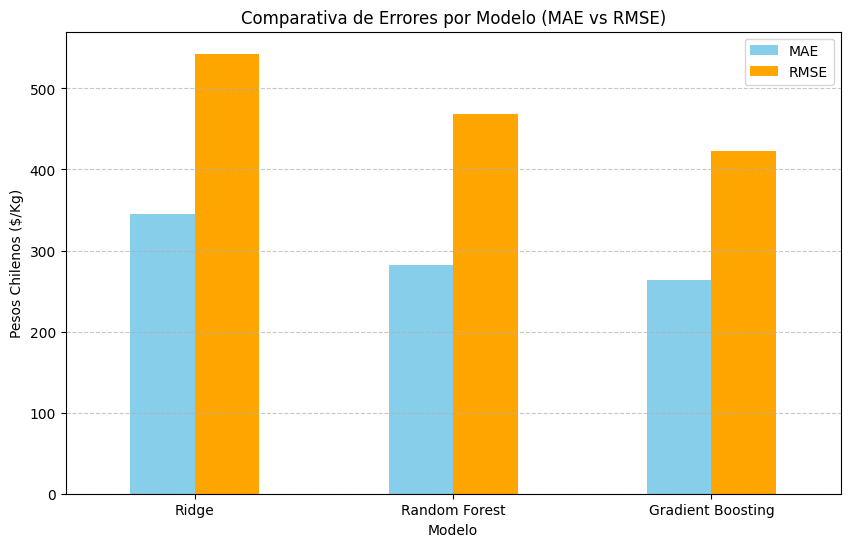

In [5]:
df_metrics[["MAE", "RMSE"]].plot(kind="bar", figsize=(10, 6), color=["skyblue", "orange"])
plt.title("Comparativa de Errores por Modelo (MAE vs RMSE)")
plt.ylabel("Pesos Chilenos ($/Kg)")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## 6. Visualización Comparativa de Explicación de Varianza (R²)

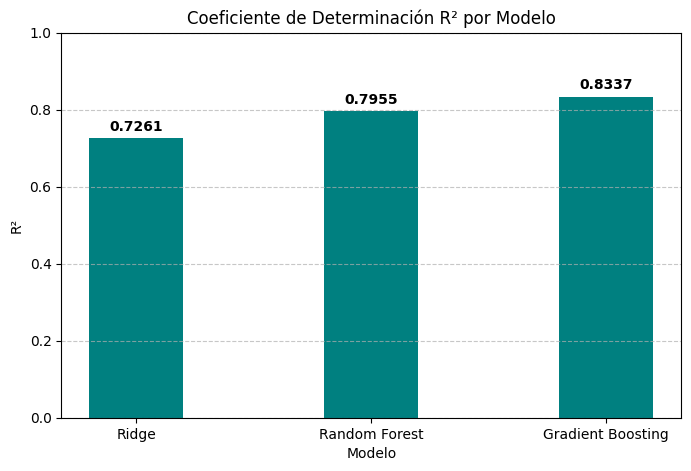

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(df_metrics.index, df_metrics["R²"], color="teal", width=0.4)
plt.title("Coeficiente de Determinación R² por Modelo")
plt.ylabel("R²")
plt.xlabel("Modelo")
plt.ylim(0, 1.0)
for i, val in enumerate(df_metrics["R²"]):
    plt.text(i, val + 0.02, f"{val:.4f}", ha="center", fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## 7. Tamaño en Disco de los Modelos (Costo de Infraestructura)

In [7]:
print("--- Tamaño de los archivos de modelos en disco ---")
for file_name in ["modelo_ridge.pkl", "modelo_random_forest.pkl", "modelo_gradient_boosting.pkl"]:
    if os.path.exists(file_name):
        size_mb = os.path.getsize(file_name) / (1024 * 1024)
        print(f"{file_name:<30}: {size_mb:>8.2f} MB")
    else:
        print(f"{file_name:<30}: [Archivo no encontrado]")

--- Tamaño de los archivos de modelos en disco ---
modelo_ridge.pkl              :     0.01 MB
modelo_random_forest.pkl      :   865.42 MB
modelo_gradient_boosting.pkl  :     1.36 MB
